# Analysing LiTS dataset

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from idssp.sonk.view import utils
from idssp.sonk.model.data import DataWrapper, VolumeWrapper
from idssp.sonk.model.training import ModelBuilder
from idssp.sonk.disk.loader import DataCollector
from monai.utils import set_determinism

from idssp.sonk import config

from IPython.display import HTML

[Config] Importing torch... (This may take a moment)
[Config] Loading configuration for environment: [LOCAL]
[Config] Warning: 'PERSISTENT_DATASET_DIR' is not set. PersistentDataset will be disabled.
[Config] Running in LOCAL environment.
[Config]   Device: cpu
[Config]   Batch Size: 1
[Config]   Val Batch Size: 1
[Config]   Workers: 0
[Config]   Data Root: /nvm-external/ct-scans/training_batch_1
[Config]   Checkpoint Dir: /home/sonk/Devel/master/thesis/pininos/files/checkpoints
[Config]   Log Dir: /home/sonk/Devel/master/thesis/pininos/files/logs
[Config]   Persistent Dataset Dir: None


In [3]:
set_determinism(seed=config.RANDOM_SEED)

## Loading the files

In [4]:
loader = DataCollector()

loader.read_dir(config.CT_ROOT, ds_source='LiTS')
loader.extract_images_and_labels()

2026-05-02 01:47:40 - INFO - idssp.sonk.disk.loader - Reading directory: /nvm-external/ct-scans/training_batch_1
2026-05-02 01:47:40 - INFO - idssp.sonk.disk.loader - Found 56 files in the directory.


In [10]:
# print the first 5 data sources to verify
loader.datasources[:5]

[{'image': '/nvm-external/ct-scans/training_batch_1/volume-0.nii.gz',
  'label': '/nvm-external/ct-scans/training_batch_1/segmentation-0.nii.gz'},
 {'image': '/nvm-external/ct-scans/training_batch_1/volume-1.nii.gz',
  'label': '/nvm-external/ct-scans/training_batch_1/segmentation-1.nii.gz'},
 {'image': '/nvm-external/ct-scans/training_batch_1/volume-10.nii.gz',
  'label': '/nvm-external/ct-scans/training_batch_1/segmentation-10.nii.gz'},
 {'image': '/nvm-external/ct-scans/training_batch_1/volume-11.nii.gz',
  'label': '/nvm-external/ct-scans/training_batch_1/segmentation-11.nii.gz'},
 {'image': '/nvm-external/ct-scans/training_batch_1/volume-12.nii.gz',
  'label': '/nvm-external/ct-scans/training_batch_1/segmentation-12.nii.gz'}]

## Analysing the data

In [24]:
desired_volume = 1
for i, pair in enumerate(loader.datasources):
    if f'volume-{desired_volume}.nii.gz' in pair['image']:
        print(f"Found desired volume: {pair['image']} at index {i}")
        index = i
        break

Found desired volume: /nvm-external/ct-scans/training_batch_1/volume-1.nii.gz at index 1


In [25]:
wrapper = DataWrapper()

print(loader.datasources[index]['image'])

wrapper.set_volume(loader.datasources[index]['image'], loader.datasources[index]['label'])

/nvm-external/ct-scans/training_batch_1/volume-1.nii.gz
2026-05-02 02:04:46 - INFO - idssp.sonk.model.data - Loading data for volume...
2026-05-02 02:04:47 - INFO - idssp.sonk.model.data - Data loaded successfully.
2026-05-02 02:04:47 - INFO - idssp.sonk.model.data - Calculating unique values in the label data...
2026-05-02 02:04:47 - INFO - idssp.sonk.model.data - Finding slice information...
2026-05-02 02:04:47 - INFO - idssp.sonk.model.data - done!


In [26]:
wrapper.print_summary_of_volume()

Volume summary:
--------------------File paths--------------------
Image path: /nvm-external/ct-scans/training_batch_1/volume-1.nii.gz
Label path: /nvm-external/ct-scans/training_batch_1/segmentation-1.nii.gz
--------------------File shapes--------------------
Image shape: (512, 512, 123)
Label shape: (512, 512, 123)
--------------------Data arrays--------------------
Image data shape: (512, 512, 123)
Mask data shape: (512, 512, 123)
--------------------- value ranges--------------------
CT intensity range: -3024.0 to 3071.0
Mask intensity range: 0 to 2
Voxel dimensions (mm): (np.float32(0.675781), np.float32(0.675781), np.float32(5.0))
--------------------Affine information--------------------
Image affine transformation matrix:
 [[  -0.67578101    0.            0.          177.19999695]
 [   0.            0.67578101    0.         -172.32409668]
 [   0.            0.            5.         -560.25      ]
 [   0.            0.            0.            1.        ]]
Human readable header 

## Visualising the data

Plotting slice 444 of volume...


IndexError: index 444 is out of bounds for axis 2 with size 123

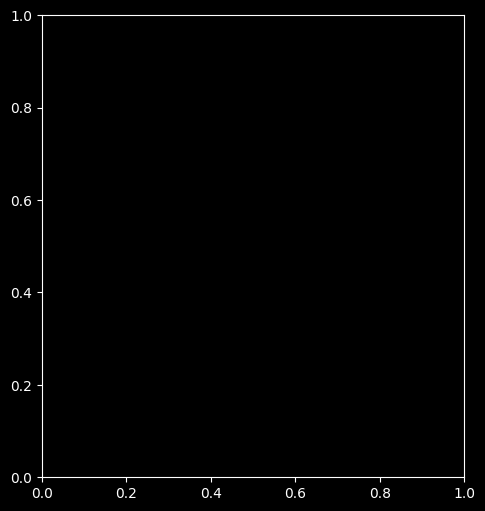

In [27]:
wrapper.plot_slice(444)

The following cell takes too much space, so just run it
locally

In [29]:
# HTML(wrapper.get_animation_motion().to_jshtml())

In [11]:
utils.slice_to_world_coordinates(wrapper.volume.image, wrapper.volume.slice_thresholds['liver']['first'])

np.float64(-335.25)

## Model training

In [4]:
import torch
import torch.optim as optim
from monai.networks.nets import UNet
from monai.losses import DiceLoss

### Data loading

In [49]:
train_files, val_files = loader.get_reproducible_split()

Split dataset into 22 training and 6 validation samples.
Split logged to LiTS_split_seed42.json


In [42]:
builder = ModelBuilder()

builder.init_data_loaders(train_files, val_files)

ModelBuilder initialized. Device set to: cpu
Creating training transforms object...
Creating validation transforms object...
Validation transforms: Using random crop for limited environment.
Initializing training and validation datasets...
Limited environment detected. Using regular Dataset.
Creating training dataloader...
Creating validation dataloader...
Data loaders initialized successfully.


### Modelling

It's gonna be a basic UNet

In [43]:
builder.init_model()

Initializing model...
Model initialized on cpu
Optimizer: AdamW | LR: 0.0001 | Weight Decay: 1e-5
Scheduler initialized: ReduceLROnPlateau (patience=5, factor=0.5)


### Training

In [ ]:
# start small, increase later
builder.train(10)

Epoch 1/10
